In [ ]:
pip install opencv-python ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.5 MB/s eta 0:00:00


In [ ]:
pip install torch torchvision opencv-python

In [ ]:
pip install rfdetr opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 23.1 MB/s eta 0:00:00


In [ ]:
import cv2
import os
from rfdetr.detr import RFDETR

def extract_and_crop_only_players(video_path, model_path, output_dir, target_class_ids, frame_skip=2, confidence_thresh=0.6):
    """
    Reads a video, loads a custom RF-DETR checkpoint,
    filters out non-player classes, crops the players, and saves the images.

    :param target_class_ids: A list of integer class indices representing players.
    :param frame_skip: Process every Nth frame. Set to 2 for higher density tracking.
    """
    os.makedirs(output_dir, exist_ok=True)

    # 1. Load the model directly from the checkpoint
    print(f"Loading RF-DETR model from {model_path}...")
    model = RFDETR.from_checkpoint(model_path)
    model.optimize_for_inference(compile=False)

    # 2. Process the video
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video at {video_path}")
        return

    frame_count = 0
    saved_count = 0

    print(f"Processing video (Targeting Class IDs: {target_class_ids}, extracting every {frame_skip} frames)...")
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Process every 2nd frame as requested
        if frame_count % frame_skip == 0:

            # rfdetr expects RGB format
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # Run inference
            detections = model.predict(rgb_frame, threshold=confidence_thresh)

            # Verify detections structure has coordinates and class tracking
            if hasattr(detections, 'xyxy') and hasattr(detections, 'class_id'):
                # Loop through both boxes and their corresponding class IDs simultaneously
                for i, (box, cid) in enumerate(zip(detections.xyxy, detections.class_id)):

                    # STRICT FILTER: Only grab the player-related classes (3, 4, 5, 6)
                    if int(cid) not in target_class_ids:
                        continue

                    # Extract coordinates for the player
                    x1, y1, x2, y2 = map(int, box)

                    # Boundary guards to keep cropping inside frame dimensions
                    h, w, _ = frame.shape
                    x1, y1 = max(0, x1), max(0, y1)
                    x2, y2 = min(w, x2), min(h, y2)

                    # Crop from original BGR frame for correct color profile saving
                    cropped_player = frame[y1:y2, x1:x2]

                    if cropped_player.size > 0:
                        filename = os.path.join(output_dir, f"player_frame_{frame_count}_class_{int(cid)}_id_{i}.jpg")
                        cv2.imwrite(filename, cropped_player)
                        saved_count += 1

        frame_count += 1

    cap.release()
    print(f"Finished! Successfully isolated and extracted {saved_count} player images to '{output_dir}'.")

# --- Run configuration ---
if __name__ == "__main__":

    # Keeping your custom mappings from the training metrics:
    # 3: player, 4: player-in-possession, 5: player-jump-shot, 6: player-shot-block
    TARGET_PLAYER_CLASS_IDS = [3, 4, 5, 6]

    extract_and_crop_only_players(
        video_path="/content/stephcurryvideo.mp4",
        model_path="/content/checkpoint_best_ema.pth",
        output_dir="/content/CROPPED_PLAYERS_6",
        target_class_ids=TARGET_PLAYER_CLASS_IDS,
        frame_skip=2  # Changed from 5 to 2
    )

[2026-06-29 07:59:14] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-29 07:59:14] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


Loading RF-DETR model from /content/checkpoint_best_ema.pth...


[2026-06-29 07:59:14] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


Processing video (Targeting Class IDs: [3, 4, 5, 6], extracting every 2 frames)...
Finished! Successfully isolated and extracted 899 player images to '/content/CROPPED_PLAYERS_6'.


In [17]:
pip install transformers pillow torch

In [28]:
import os
import glob
import pickle
import torch
from PIL import Image
from tqdm import tqdm
from transformers import AutoProcessor, SiglipVisionModel

def generate_siglip_embeddings(image_dir, output_pickle_path):
    """
    Loads cropped player images, extracts feature embeddings using Google's
    SigLIP Vision Model, and saves them to a pickle file.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model_name = "google/siglip-base-patch16-224"
    print(f"Loading SigLIP Vision Model '{model_name}'...")

    # 1. Setup Processor
    processor = AutoProcessor.from_pretrained(model_name)

    # 2. CRITICAL FIX: Load ONLY the vision architecture.
    # This ignores the text model, preventing the 'input_ids' error.
    model = SiglipVisionModel.from_pretrained(model_name).to(device)
    model.eval()

    image_paths = glob.glob(os.path.join(image_dir, "*.jpg")) + glob.glob(os.path.join(image_dir, "*.png"))

    if not image_paths:
        print(f"No images found in {image_dir}. Please verify the path.")
        return

    print(f"Found {len(image_paths)} player images. Extracting embeddings...")

    embeddings_dict = {}

    with torch.no_grad():
        for img_path in tqdm(image_paths, desc="Processing Images"):
            try:
                # Open image using PIL
                image = Image.open(img_path).convert("RGB")

                # Preprocess image
                inputs = processor(images=image, return_tensors="pt").to(device)

                # Run through the vision-only model
                outputs = model(**inputs)

                # Extract the final mathematical tensor
                image_features = outputs.pooler_output

                # Normalize the embeddings for better clustering accuracy
                image_features = image_features / image_features.norm(dim=-1, keepdim=True)

                # Convert tensor to a standard 1D NumPy array and store it
                embedding_vector = image_features.cpu().numpy().flatten()

                filename = os.path.basename(img_path)
                embeddings_dict[filename] = embedding_vector

            except Exception as e:
                print(f"\nError processing {img_path}: {e}")

    print(f"\nSaving extracted embeddings to {output_pickle_path}...")
    with open(output_pickle_path, "wb") as f:
        pickle.dump(embeddings_dict, f)

    print("Embedding generation complete!")

# --- Run configuration ---
if __name__ == "__main__":
    CROP_DIR = "/content/cropped_players"
    OUTPUT_FILE = "/content/player_embeddings.pkl"

    generate_siglip_embeddings(CROP_DIR, OUTPUT_FILE)

Using device: cuda
Loading SigLIP Vision Model 'google/siglip-base-patch16-224'...


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[transformers] SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp

Found 899 player images. Extracting embeddings...


Processing Images: 100%|██████████| 899/899 [01:06<00:00, 13.60it/s]



Saving extracted embeddings to /content/player_embeddings.pkl...
Embedding generation complete!


In [29]:
pip install umap-learn matplotlib

Loading high-dimensional embeddings from /content/player_embeddings.pkl...
Loaded 899 images with 768-dimensional vectors.
Running UMAP dimensionality reduction (768D -> 2D)...


Saving 2D coordinates to /content/umap_2d_coordinates.csv...
Generating visualization...


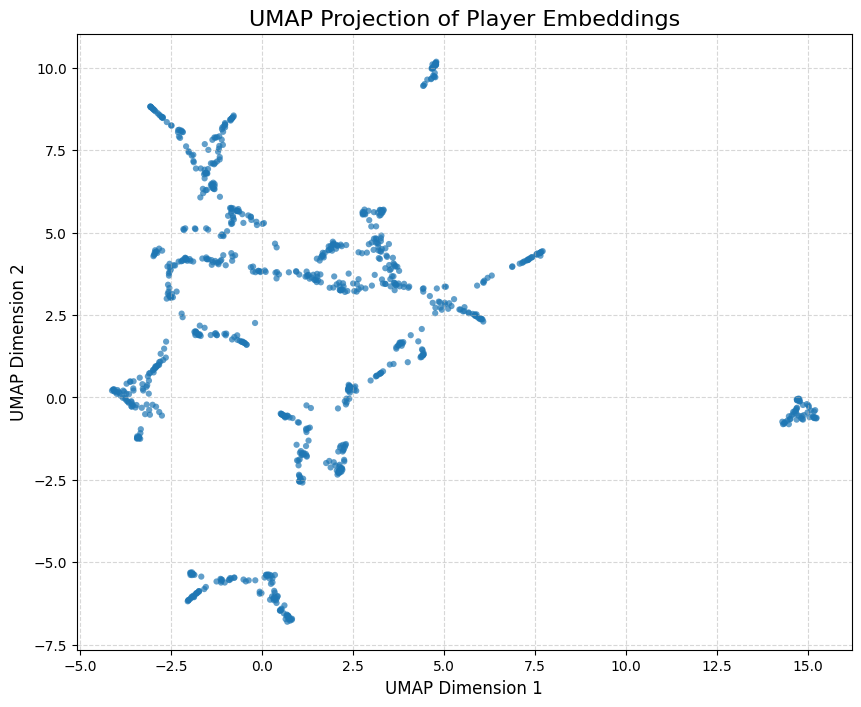

Done! You are ready for the final clustering step.


In [30]:
import os
import pickle
import numpy as np
import umap
import matplotlib.pyplot as plt

def reduce_embeddings_with_umap(input_pickle_path, output_csv_path):
    """
    Loads 768D SigLIP embeddings, reduces them to 2D using UMAP,
    saves the 2D coordinates, and visualizes the result.
    """
    if not os.path.exists(input_pickle_path):
        print(f"Error: Could not find {input_pickle_path}")
        return

    # 1. Load the embeddings
    print(f"Loading high-dimensional embeddings from {input_pickle_path}...")
    with open(input_pickle_path, "rb") as f:
        embeddings_dict = pickle.load(f)

    # Separate the dictionary into lists so UMAP can process the math
    filenames = list(embeddings_dict.keys())
    vectors = np.array(list(embeddings_dict.values()))

    print(f"Loaded {len(filenames)} images with {vectors.shape[1]}-dimensional vectors.")

    # 2. Configure and run UMAP
    # n_neighbors controls how UMAP balances local vs global structure
    # min_dist controls how tightly UMAP packs points together
    print("Running UMAP dimensionality reduction (768D -> 2D)...")
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,   # Adjust lower (e.g., 5) for smaller datasets, higher for larger
        min_dist=0.1,     # Lower value creates tighter, denser clusters
        metric='cosine',  # Cosine distance is best for image embeddings
        random_state=42   # Locks the seed so the graph looks the same every run
    )

    embeddings_2d = reducer.fit_transform(vectors)

    # 3. Save the 2D coordinates for the final clustering step
    # Saving as a simple CSV to make it easy to read into pandas later
    print(f"Saving 2D coordinates to {output_csv_path}...")
    with open(output_csv_path, "w") as f:
        f.write("filename,x,y\n")
        for i, filename in enumerate(filenames):
            x, y = embeddings_2d[i]
            f.write(f"{filename},{x},{y}\n")

    # 4. Plot the 2D map to visually confirm the clusters
    print("Generating visualization...")
    plt.figure(figsize=(10, 8))

    # Extract x and y coordinates
    x_coords = embeddings_2d[:, 0]
    y_coords = embeddings_2d[:, 1]

    # Create the scatter plot
    plt.scatter(x_coords, y_coords, s=20, alpha=0.7, c='#1f77b4', edgecolors='none')
    plt.title('UMAP Projection of Player Embeddings', fontsize=16)
    plt.xlabel('UMAP Dimension 1', fontsize=12)
    plt.ylabel('UMAP Dimension 2', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

    # Show the plot right in Colab
    plt.show()

    print("Done! You are ready for the final clustering step.")

# --- Run configuration ---
if __name__ == "__main__":
    INPUT_FILE = "/content/player_embeddings.pkl"
    OUTPUT_FILE = "/content/umap_2d_coordinates.csv"

    reduce_embeddings_with_umap(INPUT_FILE, OUTPUT_FILE)

In [31]:
pip install scikit-learn pandas

Loading data from /content/umap_2d_coordinates.csv...
Clustering players into 2 teams using K-Means...
Generating cluster map...


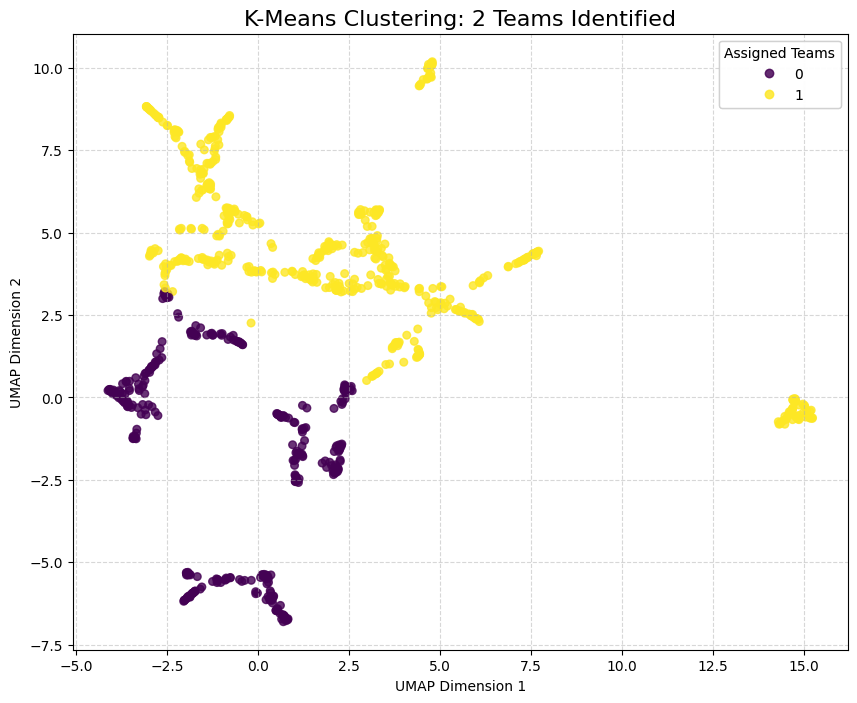

Sorting images into /content/sorted_teams...
Finished! Successfully sorted 899 player images into team folders.


In [32]:
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def cluster_and_sort_players(csv_path, source_img_dir, output_base_dir, num_teams=2):
    """
    Reads UMAP 2D coordinates, applies K-Means clustering to find teams,
    plots the results, and sorts the physical images into team folders.
    """
    if not os.path.exists(csv_path):
        print(f"Error: Could not find {csv_path}")
        return

    # 1. Load the 2D coordinates
    print(f"Loading data from {csv_path}...")
    df = pd.read_csv(csv_path)

    # Extract just the X and Y coordinates for the math
    coordinates = df[['x', 'y']].values

    # 2. Run K-Means Clustering
    # random_state ensures we get the exact same cluster assignments every time we run it
    print(f"Clustering players into {num_teams} teams using K-Means...")
    kmeans = KMeans(n_clusters=num_teams, random_state=42, n_init=10)
    df['team_cluster'] = kmeans.fit_predict(coordinates)

    # 3. Visualize the Clusters
    print("Generating cluster map...")
    plt.figure(figsize=(10, 8))

    # Scatter plot with colors assigned by the K-Means cluster
    scatter = plt.scatter(df['x'], df['y'], c=df['team_cluster'], cmap='viridis', s=30, alpha=0.8)
    plt.title(f'K-Means Clustering: {num_teams} Teams Identified', fontsize=16)
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')

    # Add a legend
    legend1 = plt.legend(*scatter.legend_elements(), title="Assigned Teams")
    plt.gca().add_artist(legend1)

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show() # Renders in Colab

    # 4. Sort the actual images into folders
    print(f"Sorting images into {output_base_dir}...")

    # Wipe the output directory if it already exists from a previous run
    if os.path.exists(output_base_dir):
        shutil.rmtree(output_base_dir)
    os.makedirs(output_base_dir)

    sorted_count = 0

    # Loop through the dataframe and copy each file to its new team folder
    for index, row in df.iterrows():
        filename = row['filename']
        team_id = row['team_cluster']

        # Create a folder for this specific team if it doesn't exist
        team_folder = os.path.join(output_base_dir, f"team_{team_id}")
        os.makedirs(team_folder, exist_ok=True)

        source_path = os.path.join(source_img_dir, filename)
        dest_path = os.path.join(team_folder, filename)

        # Copy the file
        if os.path.exists(source_path):
            shutil.copy2(source_path, dest_path)
            sorted_count += 1
        else:
            print(f"Warning: Could not find image {source_path}")

    print(f"Finished! Successfully sorted {sorted_count} player images into team folders.")

# --- Run configuration ---
if __name__ == "__main__":
    CSV_FILE = "/content/umap_2d_coordinates.csv"
    CROP_DIR = "/content/cropped_players"
    TEAM_OUTPUT_DIR = "/content/sorted_teams"

    # Set this to 2 for just the two playing teams.
    # PRO-TIP: If the referees were wearing distinct shirts and were captured
    # by your RF-DETR model as "players", you might want to set this to 3!
    NUMBER_OF_TEAMS = 2

    cluster_and_sort_players(
        csv_path=CSV_FILE,
        source_img_dir=CROP_DIR,
        output_base_dir=TEAM_OUTPUT_DIR,
        num_teams=NUMBER_OF_TEAMS
    )

In [33]:
import os
import shutil
import pickle
import numpy as np
from sklearn.cluster import KMeans

def cluster_on_raw_embeddings(pickle_path, source_img_dir, output_base_dir, num_teams=2):
    """
    Bypasses UMAP and clusters players directly on their 768D SigLIP vectors
    for significantly higher accuracy.
    """
    if not os.path.exists(pickle_path):
        print(f"Error: Could not find {pickle_path}")
        return

    # 1. Load the raw 768-dimensional embeddings
    print(f"Loading high-dimensional data from {pickle_path}...")
    with open(pickle_path, "rb") as f:
        embeddings_dict = pickle.load(f)

    filenames = list(embeddings_dict.keys())
    vectors = np.array(list(embeddings_dict.values()))

    print(f"Clustering {len(filenames)} images across {vectors.shape[1]} dimensions...")

    # 2. Run K-Means directly on the 768D space
    # We increase n_init to 20 to give the algorithm more attempts to find the perfect split
    kmeans = KMeans(n_clusters=num_teams, random_state=42, n_init=20)
    team_labels = kmeans.fit_predict(vectors)

    # 3. Sort the actual images into folders
    print(f"Sorting images into {output_base_dir}...")

    # Wipe the output directory to start fresh
    if os.path.exists(output_base_dir):
        shutil.rmtree(output_base_dir)
    os.makedirs(output_base_dir)

    sorted_count = 0

    # Loop through and copy files to their new high-accuracy folders
    for i, filename in enumerate(filenames):
        team_id = team_labels[i]

        team_folder = os.path.join(output_base_dir, f"team_{team_id}")
        os.makedirs(team_folder, exist_ok=True)

        source_path = os.path.join(source_img_dir, filename)
        dest_path = os.path.join(team_folder, filename)

        if os.path.exists(source_path):
            shutil.copy2(source_path, dest_path)
            sorted_count += 1

    print(f"Finished! Successfully sorted {sorted_count} player images using high-dimensional clustering.")

# --- Run configuration ---
if __name__ == "__main__":
    # We point this directly at the pickle file, NOT the UMAP csv
    PICKLE_FILE = "/content/player_embeddings.pkl"
    CROP_DIR = "/content/cropped_players"
    TEAM_OUTPUT_DIR = "/content/sorted_teams_high_res"

    # Assuming 2 teams, but bump to 3 if referees are getting caught in the crossfire
    NUMBER_OF_TEAMS = 2

    cluster_on_raw_embeddings(
        pickle_path=PICKLE_FILE,
        source_img_dir=CROP_DIR,
        output_base_dir=TEAM_OUTPUT_DIR,
        num_teams=NUMBER_OF_TEAMS
    )

Loading high-dimensional data from /content/player_embeddings.pkl...
Clustering 899 images across 768 dimensions...
Sorting images into /content/sorted_teams_high_res...
Finished! Successfully sorted 899 player images using high-dimensional clustering.
